In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
BASE_DIR = Path.cwd().parents[0]
ASPI_PATH = BASE_DIR / "data" / "raw" / "aspi" / "ASPI_2014_2024_raw.csv"

aspi = pd.read_csv(ASPI_PATH)
aspi["Date"] = pd.to_datetime(aspi["Date"])
aspi = aspi.sort_values("Date").reset_index(drop=True)

aspi.head()


,Date,Open,High,Low,Close,Volume
0,2014-01-02,5913.479980,5972.100098,5912.779785,5968.040039,28247700
1,2014-01-03,5968.359863,6007.790039,5956.709961,5973.799805,47510500
2,2014-01-06,5974.500000,5975.000000,5938.259766,5944.990234,23959600
3,2014-01-07,5945.049805,5989.419922,5942.620117,5977.069824,25385500
4,2014-01-08,5975.020020,6064.689941,5973.240234,6054.470215,49248500


In [5]:
print(aspi.info())
print(aspi.describe())
print("Date range:", aspi["Date"].min(), "→", aspi["Date"].max())


<class 'pandas.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1778 non-null   datetime64[us]
 1   Open    1778 non-null   float64       
 2   High    1778 non-null   float64       
 3   Low     1778 non-null   float64       
 4   Close   1778 non-null   float64       
 5   Volume  1778 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 83.5 KB
None
                             Date         Open         High          Low  \
count                        1778  1778.000000  1778.000000  1778.000000   
mean   2017-10-17 15:58:55.208099  6444.778169  6469.394244  6421.705881   
min           2014-01-02 00:00:00  4283.069824  4392.430176  4219.029785   
25%           2015-11-13 18:00:00  5992.754883  6025.140137  5977.307495   
50%           2017-10-09 12:00:00  6405.479980  6420.925049  6396.679932   
75%           2019-08-

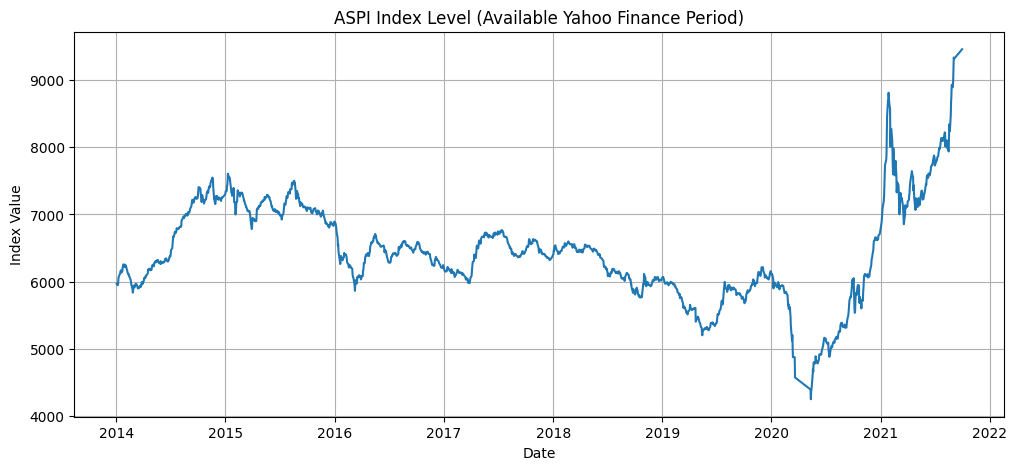

In [6]:
plt.figure(figsize=(12,5))
plt.plot(aspi["Date"], aspi["Close"])
plt.title("ASPI Index Level (Available Yahoo Finance Period)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.grid(True)
plt.show()


In [7]:
aspi["Return"] = aspi["Close"].pct_change()
aspi = aspi.dropna()

aspi[["Date", "Return"]].head()


,Date,Return
1,2014-01-03,0.000965
2,2014-01-06,-0.004823
3,2014-01-07,0.005396
4,2014-01-08,0.012950
5,2014-01-09,0.002456


In [8]:
aspi["Vol_30"] = aspi["Return"].rolling(30).std()
aspi["Vol_90"] = aspi["Return"].rolling(90).std()


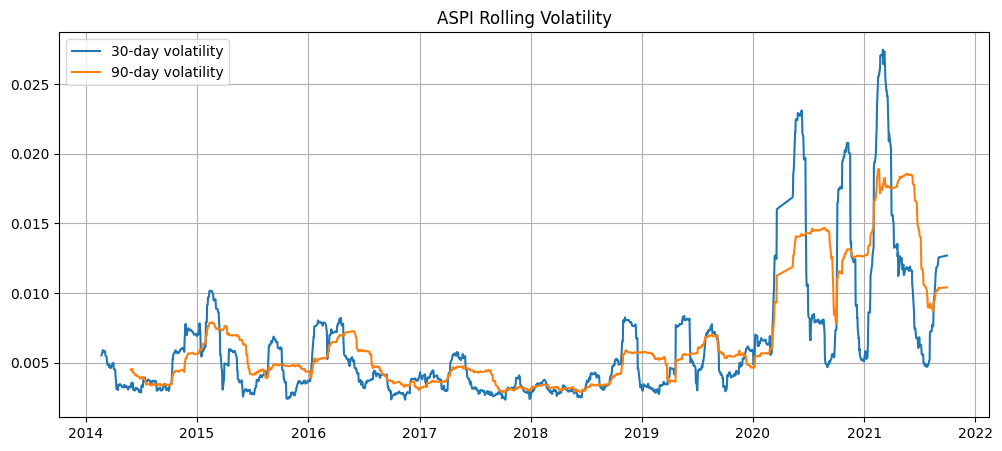

In [9]:
plt.figure(figsize=(12,5))
plt.plot(aspi["Date"], aspi["Vol_30"], label="30-day volatility")
plt.plot(aspi["Date"], aspi["Vol_90"], label="90-day volatility")
plt.legend()
plt.title("ASPI Rolling Volatility")
plt.grid(True)
plt.show()


In [10]:
threshold = aspi["Vol_30"].quantile(0.90)
aspi["High_Risk"] = aspi["Vol_30"] > threshold

aspi["High_Risk"].value_counts()


High_Risk
False    1602
True      175
Name: count, dtype: int64

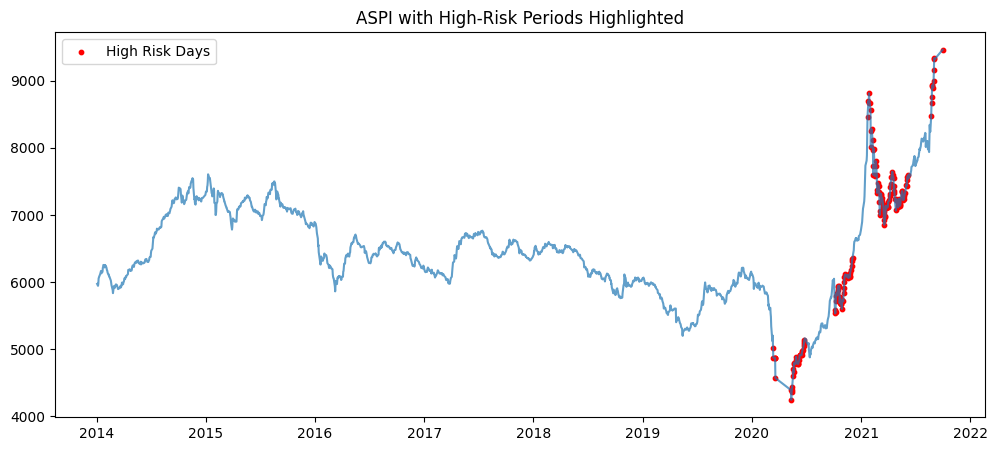

In [11]:
plt.figure(figsize=(12,5))
plt.plot(aspi["Date"], aspi["Close"], alpha=0.7)

plt.scatter(
    aspi.loc[aspi["High_Risk"], "Date"],
    aspi.loc[aspi["High_Risk"], "Close"],
    color="red",
    s=10,
    label="High Risk Days"
)

plt.title("ASPI with High-Risk Periods Highlighted")
plt.legend()
plt.show()
